# CodeAlpha Internship Task 1: Unemployment Analysis in India
**Author**: Murali  
**Objective**: Perform Exploratory Data Analysis (EDA), header normalization, missing value handling, time-series visualization, and COVID-19 lockdown impact analysis on Indian unemployment data.

## 1. Import Libraries & Setup Environment

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('crest')

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load & Clean Datasets
- Normalize column headers (strip trailing spaces, lowercase, spaces to underscores)
- Handle missing values
- Convert dates with `pd.to_datetime`

In [2]:
df1 = pd.read_csv('Unemployment in India.csv')
df1.columns = df1.columns.str.strip().str.lower().str.replace(' ', '_')
df1 = df1.dropna(subset=['region']).copy()
df1['date'] = pd.to_datetime(df1['date'].str.strip(), format='%d-%m-%Y')
df1['area'] = df1['area'].str.strip()
df1['region'] = df1['region'].str.strip()

df2 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
df2.columns = df2.columns.str.strip().str.lower().str.replace(' ', '_')
if 'region.1' in df2.columns:
    df2.rename(columns={'region.1': 'zone'}, inplace=True)
df2['date'] = pd.to_datetime(df2['date'].str.strip(), format='%d-%m-%Y')
df2['region'] = df2['region'].str.strip()

print('Dataset 1 Shape:', df1.shape)
print('Dataset 2 Shape:', df2.shape)

Dataset 1 Shape: (740, 7)
Dataset 2 Shape: (267, 9)


## 3. Summary Statistics: Rural vs. Urban & Regional Distribution

In [3]:
area_stats = df1.groupby('area')[['estimated_unemployment_rate_(%)', 'estimated_employed', 'estimated_labour_participation_rate_(%)']].agg(['mean', 'median', 'std'])
display(area_stats.round(2))

region_stats = df2.groupby('region')['estimated_unemployment_rate_(%)'].agg(['mean', 'median', 'max']).sort_values(by='mean', ascending=False)
display(region_stats.head(10).round(2))

estimated_unemployment_rate_(%)               estimated_employed  \
                                 mean median    std               mean   
area                                                                     
Rural                           10.32   6.76  10.04        10192852.57   
Urban                           13.17   9.97  11.17         4388625.58   

                             estimated_labour_participation_rate_(%)         \
          median         std                                    mean median   
area                                                                          
Rural  7508747.0  9847886.12                                   44.46  42.56   
Urban  2821456.0  4411701.68                                   40.90  40.21   

             
        std  
area         
Rural  8.85  
Urban  6.92

,mean,median,max
region,,,
Haryana,27.48,26.24,43.22
Tripura,25.06,24.82,41.23
Jharkhand,19.54,11.20,59.23
Bihar,19.47,13.11,46.64
Delhi,18.41,16.86,42.27
Puducherry,17.94,5.62,75.85
Jammu & Kashmir,16.48,16.17,21.08
Himachal Pradesh,16.07,16.31,26.95
Rajasthan,15.87,15.54,24.15


## 4. Impact of COVID-19 Lockdowns (2020 Spikes)

In [4]:
lockdown_df = df2[(df2['date'] >= '2020-03-01') & (df2['date'] <= '2020-06-30')]
pre_lockdown = df2[df2['date'] < '2020-03-01']
print(f"Pre-Lockdown Average Unemployment: {pre_lockdown['estimated_unemployment_rate_(%)'].mean():.2f}%")
print(f"Lockdown Peak Average Unemployment: {lockdown_df['estimated_unemployment_rate_(%)'].mean():.2f}%")

Pre-Lockdown Average Unemployment: 9.23%
Lockdown Peak Average Unemployment: 16.74%


## 5. Visual Trend Analysis & Output Export

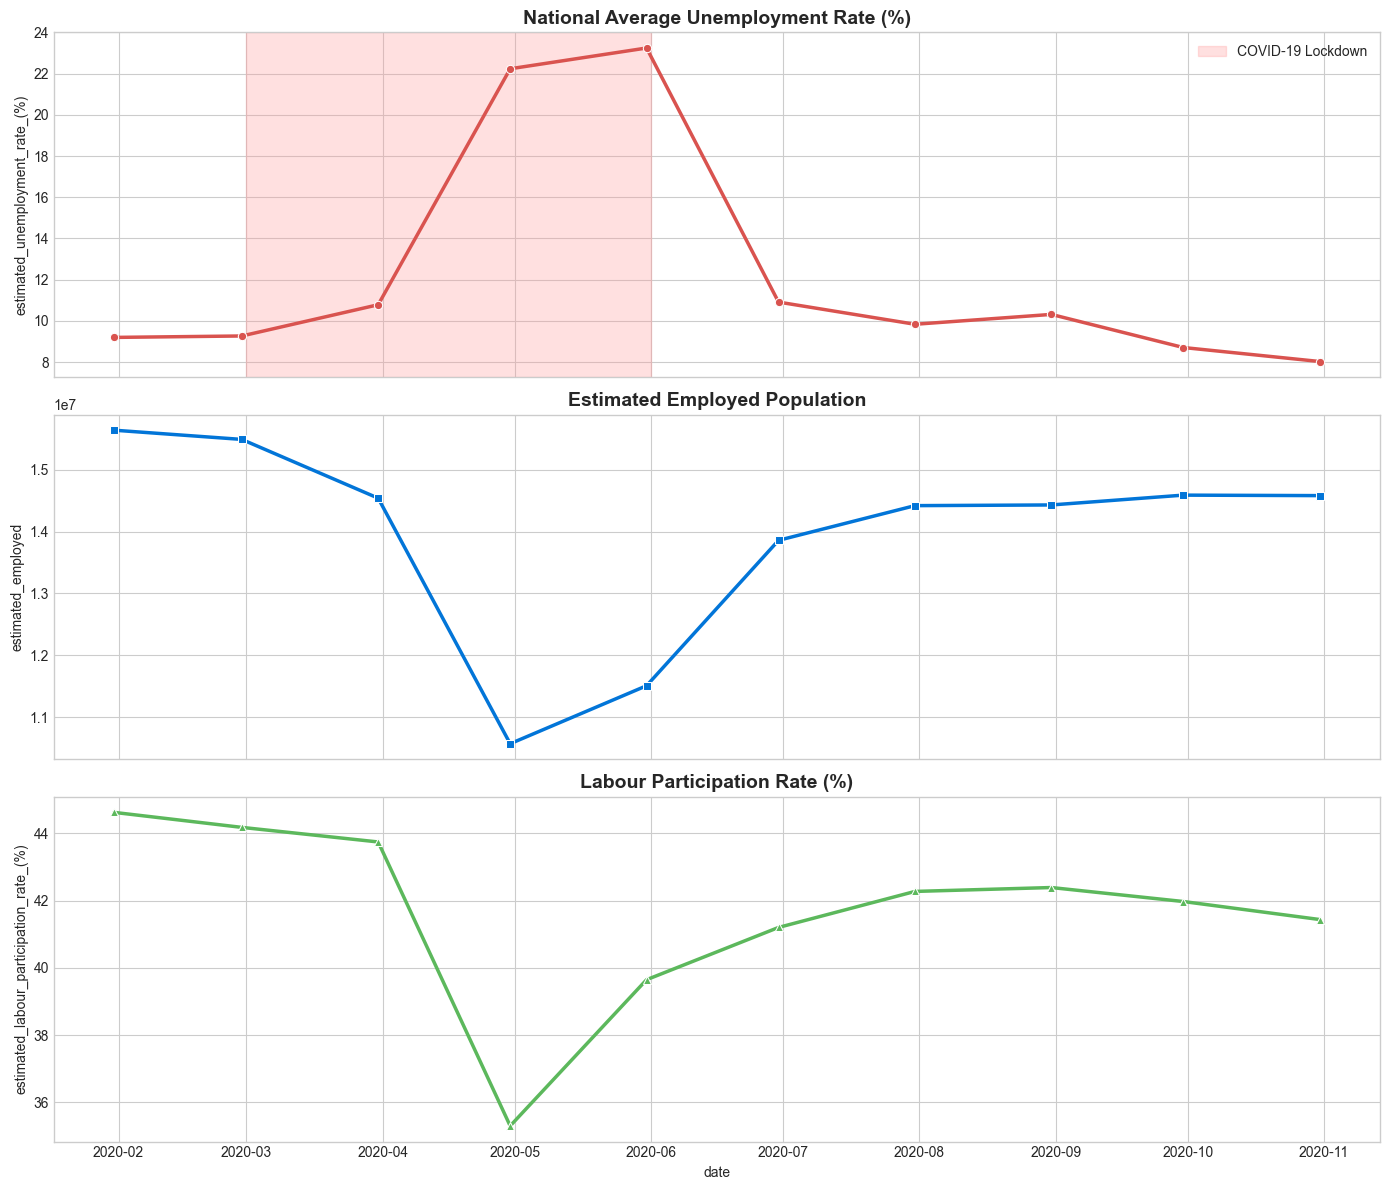

In [5]:
monthly_trend = df2.groupby('date')[['estimated_unemployment_rate_(%)', 'estimated_employed', 'estimated_labour_participation_rate_(%)']].mean().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
sns.lineplot(ax=axes[0], data=monthly_trend, x='date', y='estimated_unemployment_rate_(%)', marker='o', color='#d9534f', linewidth=2.5)
axes[0].set_title('National Average Unemployment Rate (%)', fontsize=14, fontweight='bold')
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'), color='#ff9999', alpha=0.3, label='COVID-19 Lockdown')
axes[0].legend()

sns.lineplot(ax=axes[1], data=monthly_trend, x='date', y='estimated_employed', marker='s', color='#0275d8', linewidth=2.5)
axes[1].set_title('Estimated Employed Population', fontsize=14, fontweight='bold')

sns.lineplot(ax=axes[2], data=monthly_trend, x='date', y='estimated_labour_participation_rate_(%)', marker='^', color='#5cb85c', linewidth=2.5)
axes[2].set_title('Labour Participation Rate (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/unemployment_time_series_trends.png', dpi=300)
plt.show()